In [1]:
!unzip -q "/content/drive/MyDrive/deep/archive.zip" -d "/content/dataset/"

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [3]:

INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [4]:
TRAIN = "train/"
TEST = "test/"

DATASET_PATH = "/content/dataset/UCI-HAR Dataset/"

def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')
                row_clean = row_clean.strip()
                serie = row_clean.split(' ')
                serie_array = np.array(serie, dtype=np.float32)
                series_list.append(serie_array)

        X_signals.append(series_list)

    X_signals = np.array(X_signals)
    return np.transpose(X_signals, (1, 2, 0))

def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    return np.array(labels, dtype=np.int32) - 1

In [5]:
X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial Signals/" + signal + "train.txt" for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial Signals/" + signal + "test.txt" for signal in INPUT_SIGNAL_TYPES
]

y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"


X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
y_train shape: (7352,)
y_test shape: (2947,)


In [6]:
# 1. GPU 사용 가능 여부 확인
device_available = torch.cuda.is_available()
print(f"GPU 사용 가능 여부: {device_available}")

if device_available:
    device_name = torch.cuda.get_device_name(0)
    print(f"사용 중인 GPU 장치: {device_name}")

    device = torch.device("cuda")
    x = torch.tensor([1.0, 2.0]).to(device)
    print(f"텐서가 할당된 장치: {x.device}")
else:
    print("GPU를 인식하지 못했습니다. 설정을 다시 확인해주세요.")

GPU 사용 가능 여부: True
사용 중인 GPU 장치: Tesla T4
텐서가 할당된 장치: cuda:0


In [7]:
class HAR_Dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)  # (B, 9, 128)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [8]:
train_dataset = HAR_Dataset(X_train, y_train)
test_dataset  = HAR_Dataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# **모델 구현. 이해 제대로 할 것.**

In [17]:
class CNN1D(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(9, 64, kernel_size=5)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5)

        self.pool = nn.MaxPool1d(2)

        self.fc = nn.Linear(128 * 58, 6)

    def forward(self, x):
        # x: (B, 9, 128)

        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = F.relu(self.conv2(x))
        x = torch.flatten(x, 1)

        x = self.fc(x)
        return x

In [18]:
def train(model, loader):
    model.train()

    total_loss = 0

    for X, y in loader:
        optimizer.zero_grad()

        outputs = model(X)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in loader:
            outputs = model(X)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [19]:
model = CNN1D()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(20):
    loss = train(model, train_loader)
    acc = evaluate(model, test_loader)

    print(f"Epoch {epoch+1}: loss={loss:.4f}, acc={acc:.4f}")

Epoch 1: loss=0.4832, acc=0.8239
Epoch 2: loss=0.1510, acc=0.8938
Epoch 3: loss=0.1162, acc=0.8985
Epoch 4: loss=0.1126, acc=0.9114
Epoch 5: loss=0.1078, acc=0.9036
Epoch 6: loss=0.1038, acc=0.9179
Epoch 7: loss=0.0964, acc=0.9019
Epoch 8: loss=0.1003, acc=0.9175
Epoch 9: loss=0.0962, acc=0.9148
Epoch 10: loss=0.0900, acc=0.9203
Epoch 11: loss=0.0811, acc=0.9203
Epoch 12: loss=0.0810, acc=0.9104
Epoch 13: loss=0.0870, acc=0.9016
Epoch 14: loss=0.1075, acc=0.8738
Epoch 15: loss=0.0803, acc=0.9125
Epoch 16: loss=0.0653, acc=0.9131
Epoch 17: loss=0.0627, acc=0.9070
Epoch 18: loss=0.0579, acc=0.9145
Epoch 19: loss=0.0575, acc=0.9199
Epoch 20: loss=0.0568, acc=0.9165


In [20]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for X, y in test_loader:
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds)
        all_labels.append(y)

all_preds = torch.cat(all_preds).cpu().numpy()
all_labels = torch.cat(all_labels).cpu().numpy()

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(all_labels, all_preds)

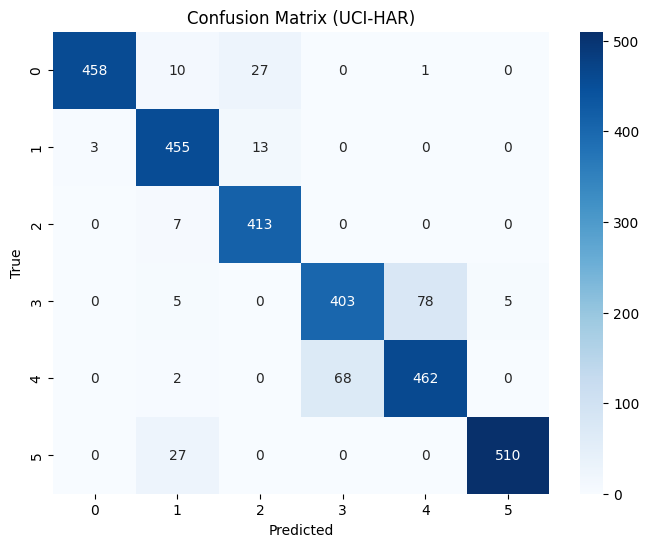

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (UCI-HAR)")
plt.show()